In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

🔵 Spearman coefficient across all datasets and significant features

In [62]:
c25_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_CaSupp_25.csv")
konv_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_konv.csv")
vmi40_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi40.csv")
vmi80_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi80.csv")
vmi120_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi120.csv")

In [63]:
vmi40_df

,Feature,spearman_corr,p_value,significant
0,original_glcm_Idm,0.505298,0.000010,True
1,original_glcm_Id,0.504476,0.000010,True
2,gradient_gldm_LowGrayLevelEmphasis,0.498429,0.000013,True
3,gradient_glrlm_LongRunLowGrayLevelEmphasis,0.486518,0.000022,True
4,gradient_glrlm_LowGrayLevelRunEmphasis,0.485951,0.000023,True
...,...,...,...,...
196,original_glrlm_RunLengthNonUniformityNormalized,-0.476945,0.000034,True
197,original_glcm_DifferenceEntropy,-0.477913,0.000033,True
198,original_glrlm_ShortRunEmphasis,-0.478571,0.000032,True
199,original_glcm_DifferenceAverage,-0.482882,0.000026,True


🔵 Sum of spearman coef for every df

In [64]:
dfs = [c25_df, konv_df, vmi40_df, vmi80_df, vmi120_df]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

feature_name = 'spearman_corr'

for name, df in zip(dataset_names, dfs):
    if feature_name in df.columns:
        total_abs_sum = df[feature_name].abs().sum()
        print(f"{name}: {total_abs_sum:.4f}")

CaSupp_25: 47.6092
Konv: 50.0237
VMI_40: 51.8355
VMI_80: 50.8494
VMI_120: 50.0901


🔵 Number of significant features for every df

In [65]:
dfs = [c25_df, konv_df, vmi40_df, vmi80_df, vmi120_df]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

pval_column = 'p_value'

for name, df in zip(dataset_names, dfs):
    count_significant = (df[pval_column] < 0.05).sum()
    print(f"{name}: {count_significant} significant features (p < 0.05)")

CaSupp_25: 100 significant features (p < 0.05)
Konv: 107 significant features (p < 0.05)
VMI_40: 109 significant features (p < 0.05)
VMI_80: 108 significant features (p < 0.05)
VMI_120: 106 significant features (p < 0.05)


🔵 Correlation between significant features and selection just group of that based on spearman_coef

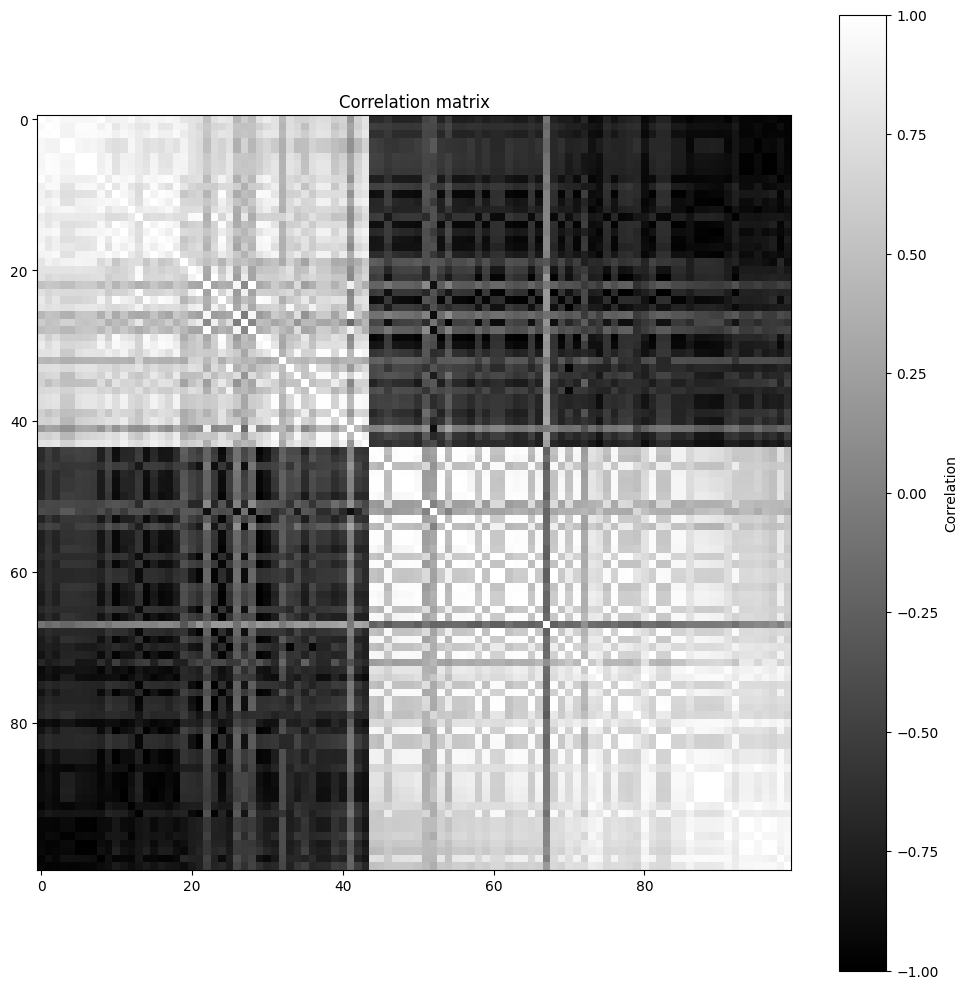

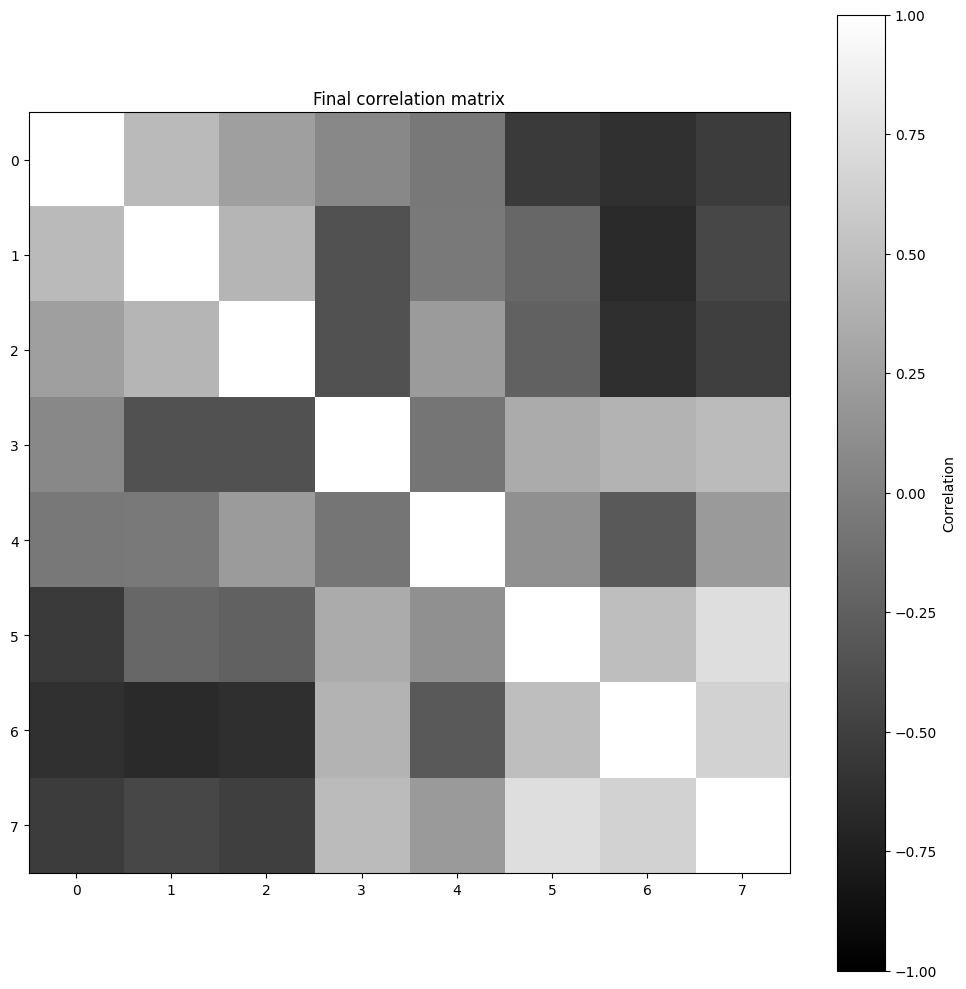

Significant before: 100
Significant after: 8

['original_glcm_Idn', 'original_firstorder_Kurtosis', 'gradient_firstorder_Skewness', 'original_glszm_ZoneEntropy', 'gradient_glcm_Imc1', 'gradient_gldm_SmallDependenceLowGrayLevelEmphasis', 'original_ngtdm_Contrast', 'gradient_firstorder_10Percentile']


In [66]:
spearman_c25_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_CaSupp_25.csv")
features_df = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
significant_features = spearman_c25_df.loc[spearman_c25_df['p_value'] < 0.05, 'Feature']

scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features_df[significant_features]),
                               columns=features_df[significant_features].columns,
                               index=features_df[significant_features].index)

corr_matrix = features_scaled.corr(method='spearman')
plt.figure(figsize=(10,10))
plt.imshow(corr_matrix, cmap='gray', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

# FEATURES FILTRATION
remaining_features = list(significant_features)
threshold = 0.75

while True:
    corr_matrix = features_scaled[remaining_features].corr(method='spearman').abs()
    np.fill_diagonal(corr_matrix.values, 0)
    max_corr = corr_matrix.values.max()
    if max_corr <= threshold:
        break

    max_pos = np.unravel_index(np.argmax(corr_matrix.values), corr_matrix.shape)
    feat1 = corr_matrix.columns[max_pos[0]]
    feat2 = corr_matrix.columns[max_pos[1]]
    spearman1 = spearman_c25_df.loc[spearman_c25_df['Feature'] == feat1, 'spearman_corr'].values[0]
    spearman2 = spearman_c25_df.loc[spearman_c25_df['Feature'] == feat2, 'spearman_corr'].values[0]

    if abs(spearman1) >= abs(spearman2):
        to_remove = feat2
    else:
        to_remove = feat1
    remaining_features.remove(to_remove)

final_corr = features_scaled[remaining_features].corr(method='spearman')
plt.figure(figsize=(10,10))
plt.imshow(final_corr, cmap='gray', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title("Final correlation matrix")
plt.tight_layout()
plt.show()

print(f"Significant before: {len(significant_features)}")
print(f"Significant after: {len(remaining_features)}")
print()
print(remaining_features)

🔵 Kruskal-Wallis test across all datasets

In [67]:
c25_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_CaSupp_25.csv")
konv_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_konv.csv")
vmi40_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi40.csv")
vmi80_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi80.csv")
vmi120_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi120.csv")

In [68]:
c25_df

,Feature,H_all,p_all,p(1-2),p(1-3),p(2-3)
0,n_lesions,2.160514,0.339508,0.848047,0.276180,0.152327
1,original_shape_Elongation,0.092584,0.954763,0.701671,0.912449,1.000000
2,original_shape_Flatness,2.343074,0.309890,0.609523,0.344369,0.122590
3,original_shape_LeastAxisLength,0.393547,0.821377,0.565563,0.895032,0.617408
4,original_shape_MajorAxisLength,0.433933,0.804957,0.881577,0.676086,0.495762
...,...,...,...,...,...,...
196,gradient_ngtdm_Busyness,3.771263,0.151733,0.047797,0.344369,0.388237
197,gradient_ngtdm_Coarseness,1.307103,0.520195,0.277766,0.628542,0.467480
198,gradient_ngtdm_Complexity,3.722654,0.155466,0.067220,0.172763,0.601508
199,gradient_ngtdm_Contrast,6.005401,0.049653,0.016181,0.146686,0.328892


🔵 Sum of H from K-W test for every df

In [69]:
dfs = [c25_df, konv_df, vmi40_df, vmi80_df, vmi120_df]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

feature_name = 'H_all'

for name, df in zip(dataset_names, dfs):
    total_abs_sum = df[feature_name].abs().sum()
    print(f"{name}: {total_abs_sum:.4f}")

CaSupp_25: 1573.6804
Konv: 1557.6256
VMI_40: 1827.6063
VMI_80: 1685.8397
VMI_120: 1595.7775


🔵 Number of significant differences between stages

In [70]:
def count_significant(row):
    p_vals = [row["p(1-2)"], row["p(1-3)"], row["p(2-3)"]]
    return sum(p < 0.05 for p in p_vals)

dfs = [c25_df, konv_df, vmi40_df, vmi80_df, vmi120_df]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

for name, df in zip(dataset_names, dfs):
    df["sig_count"] = df.apply(count_significant, axis=1)

    count_0 = (df["sig_count"] == 0).sum()
    count_1 = (df["sig_count"] == 1).sum()
    count_2 = (df["sig_count"] == 2).sum()
    count_3 = (df["sig_count"] == 3).sum()

    print(f"Dataset: {name}")
    print(f"Features with 0 significant pairs: {count_0}")
    print(f"Features with 1 significant pair:  {count_1}")
    print(f"Features with 2 significant pairs: {count_2}")
    print(f"Features with 3 significant pairs: {count_3}")
    print()

Dataset: CaSupp_25
Features with 0 significant pairs: 79
Features with 1 significant pair:  30
Features with 2 significant pairs: 92
Features with 3 significant pairs: 0

Dataset: Konv
Features with 0 significant pairs: 86
Features with 1 significant pair:  16
Features with 2 significant pairs: 99
Features with 3 significant pairs: 0

Dataset: VMI_40
Features with 0 significant pairs: 68
Features with 1 significant pair:  24
Features with 2 significant pairs: 109
Features with 3 significant pairs: 0

Dataset: VMI_80
Features with 0 significant pairs: 85
Features with 1 significant pair:  17
Features with 2 significant pairs: 99
Features with 3 significant pairs: 0

Dataset: VMI_120
Features with 0 significant pairs: 87
Features with 1 significant pair:  17
Features with 2 significant pairs: 97
Features with 3 significant pairs: 0



🔵 Correlation between significant features and selection just group of that based on H calculated by K-W test

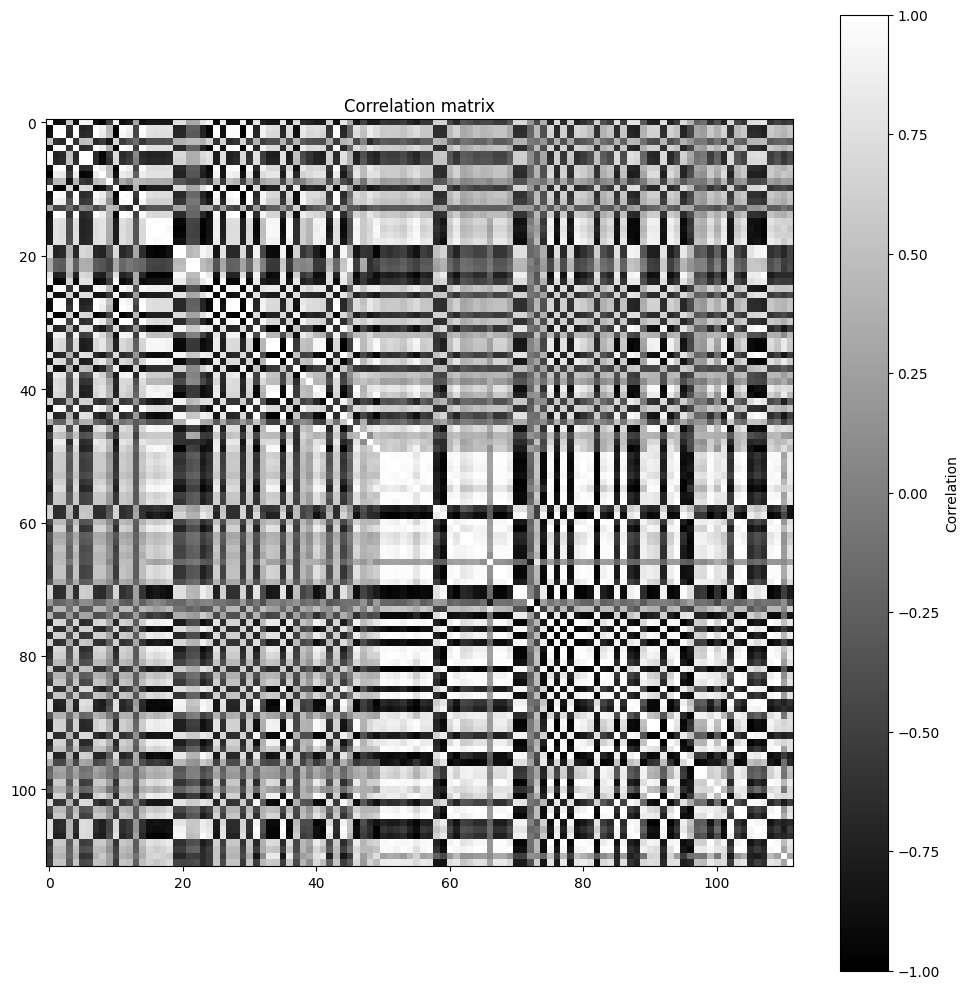

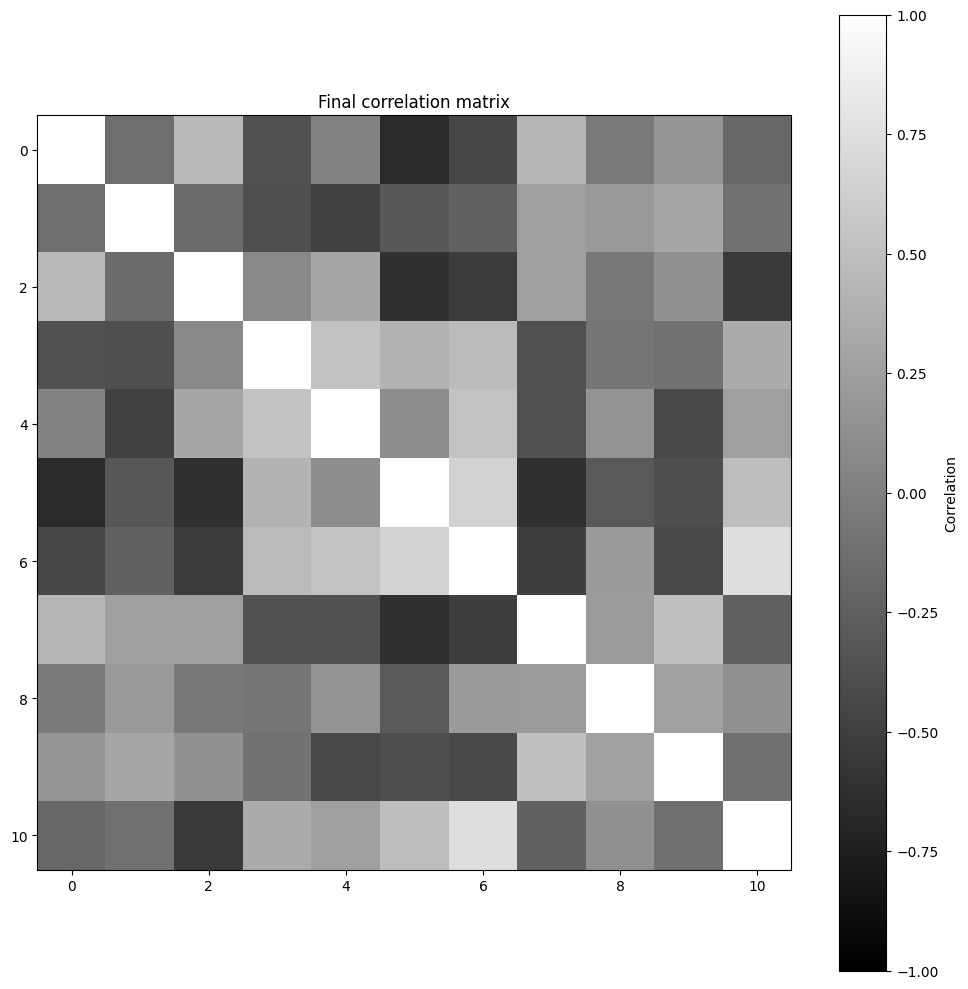

Significant before: 112
Significant after: 11

['original_firstorder_Kurtosis', 'original_glcm_ClusterShade', 'original_glcm_Idn', 'original_glszm_ZoneEntropy', 'original_ngtdm_Complexity', 'original_ngtdm_Contrast', 'gradient_firstorder_10Percentile', 'gradient_firstorder_Skewness', 'gradient_glcm_Imc1', 'gradient_glszm_GrayLevelNonUniformityNormalized', 'gradient_gldm_SmallDependenceLowGrayLevelEmphasis']


In [71]:
kw_c25_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_CaSupp_25.csv")
features_df = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
significant_features = kw_c25_df.loc[kw_c25_df['p_all'] < 0.05, 'Feature']

scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features_df[significant_features]),
                               columns=features_df[significant_features].columns,
                               index=features_df[significant_features].index)

corr_matrix = features_scaled.corr(method='spearman')
plt.figure(figsize=(10,10))
plt.imshow(corr_matrix, cmap='gray', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

# FEATURES FILTRATION
remaining_features = list(significant_features)
threshold = 0.75

while True:
    corr_matrix = features_scaled[remaining_features].corr(method='spearman').abs()

    np.fill_diagonal(corr_matrix.values, 0)
    max_corr = corr_matrix.values.max()
    if max_corr <= threshold:
        break

    max_pos = np.unravel_index(np.argmax(corr_matrix.values), corr_matrix.shape)
    feat1 = corr_matrix.columns[max_pos[0]]
    feat2 = corr_matrix.columns[max_pos[1]]
    spearman1 = kw_c25_df.loc[kw_c25_df['Feature'] == feat1, 'H_all'].values[0]
    spearman2 = kw_c25_df.loc[kw_c25_df['Feature'] == feat2, 'H_all'].values[0]

    if abs(spearman1) >= abs(spearman2):
        to_remove = feat2
    else:
        to_remove = feat1
    remaining_features.remove(to_remove)

final_corr = features_scaled[remaining_features].corr(method='spearman')
plt.figure(figsize=(10,10))
plt.imshow(final_corr, cmap='gray', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title("Final correlation matrix")
plt.tight_layout()
plt.show()

print(f"Significant before: {len(significant_features)}")
print(f"Significant after: {len(remaining_features)}")
print()
print(remaining_features)

🔵 ALPHABETICALLY SORTED DFS FROM SPEARMAN

In [72]:
c25_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_CaSupp_25.csv")
konv_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_konv.csv")
vmi40_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi40.csv")
vmi80_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi80.csv")
vmi120_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi120.csv")

dfs = [c25_df, konv_df, vmi40_df, vmi80_df, vmi120_df]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

filtered_dfs = []
for name, df in zip(dataset_names, dfs):
    temp = df[df['p_value'] < 0.05][['Feature', 'p_value']].copy()
    temp.rename(columns={'p_value': name}, inplace=True)
    filtered_dfs.append(temp)

merged_df = filtered_dfs[0]
for temp in filtered_dfs[1:]:
    merged_df = pd.merge(merged_df, temp, on='Feature', how='outer')

merged_df = merged_df.sort_values(by='Feature').reset_index(drop=True)
merged_df.to_csv(r"D:\CSV\significant_features_across_dfs.csv", index=False)
merged_df

,Feature,CaSupp_25,Konv,VMI_40,VMI_80,VMI_120
0,gradient_firstorder_10Percentile,0.000005,0.000041,0.000012,0.000020,0.000055
1,gradient_firstorder_90Percentile,0.022046,0.002337,0.004245,0.002305,0.001642
2,gradient_firstorder_Entropy,0.005647,0.002024,0.000899,0.003091,0.002303
3,gradient_firstorder_InterquartileRange,0.010172,0.003910,0.003286,0.004112,0.003432
4,gradient_firstorder_Kurtosis,NaN,0.006072,0.031867,0.041497,NaN
...,...,...,...,...,...,...
121,original_glszm_LargeAreaLowGrayLevelEmphasis,0.041904,0.017855,0.001765,0.010977,0.009215
122,original_glszm_ZoneEntropy,0.023450,0.041825,0.014770,0.010074,0.014894
123,original_glszm_ZonePercentage,0.002927,0.000333,0.000700,0.000441,0.000731
124,original_glszm_ZoneVariance,0.029001,0.005265,0.006821,0.007638,0.008017


🔵 ALPHABETICALLY SORTED DFS FROM K-W test

In [73]:
c25_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_CaSupp_25.csv")
konv_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_konv.csv")
vmi40_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi40.csv")
vmi80_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi80.csv")
vmi120_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi120.csv")

dfs = [c25_df, konv_df, vmi40_df, vmi80_df, vmi120_df]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

filtered_dfs = []
for name, df in zip(dataset_names, dfs):
    temp = df[df['p_all'] < 0.05][['Feature', 'p_all']].copy()
    temp.rename(columns={'p_all': name}, inplace=True)
    filtered_dfs.append(temp)

merged_df = filtered_dfs[0]
for temp in filtered_dfs[1:]:
    merged_df = pd.merge(merged_df, temp, on='Feature', how='outer')

merged_df = merged_df.sort_values(by='Feature').reset_index(drop=True)
merged_df.to_csv(r"D:\CSV\K-W_features_across_dfs.csv", index=False)
merged_df

,Feature,CaSupp_25,Konv,VMI_40,VMI_80,VMI_120
0,gradient_firstorder_10Percentile,0.000038,0.000139,0.000090,0.000084,0.000161
1,gradient_firstorder_90Percentile,0.004591,0.001319,0.001342,0.000748,0.000511
2,gradient_firstorder_Entropy,0.003227,0.001383,0.000592,0.000635,0.000460
3,gradient_firstorder_InterquartileRange,0.008614,0.003186,0.001620,0.001659,0.001582
4,gradient_firstorder_Kurtosis,NaN,0.049274,NaN,NaN,NaN
...,...,...,...,...,...,...
127,original_glszm_ZoneVariance,NaN,0.045229,0.045856,NaN,NaN
128,original_ngtdm_Busyness,NaN,NaN,0.036123,NaN,NaN
129,original_ngtdm_Complexity,0.033504,NaN,0.003903,NaN,NaN
130,original_ngtdm_Contrast,0.001638,0.002838,0.009853,0.001111,0.000473
